In [1]:
import tmm

In [ ]:
from __future__ import division, print_function, absolute_import

from tmm.tmm_core import (coh_tmm, unpolarized_RT, ellips,
                       position_resolved, find_in_structure_with_inf)

from numpy import pi, linspace, inf, array
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

try:
    import colorpy.illuminants
    import colorpy.colormodels
    from . import color
    colors_were_imported = True
except ImportError:
    # without colorpy, you can't run sample5(), but everything else is fine.
    colors_were_imported = False


# "5 * degree" is 5 degrees expressed in radians
# "1.2 / degree" is 1.2 radians expressed in degrees
degree = pi/180

Text(0.5, 1.0, 'Reflection of unpolarized light at 0$^\\circ$ incidence (blue), 45$^\\circ$ (purple)')

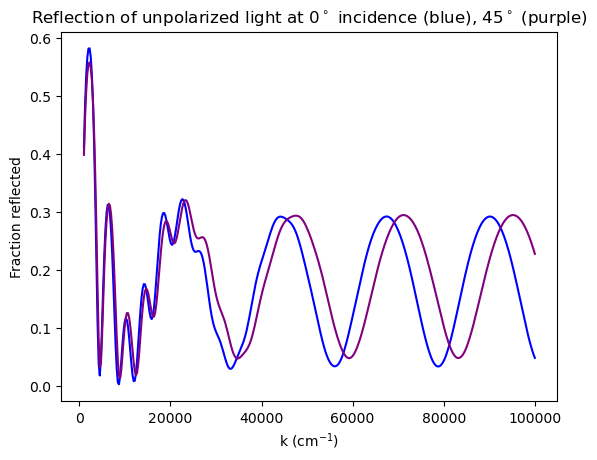

In [ ]:

"""
Here's a thin non-absorbing layer, on top of a thick absorbing layer, with
air on both sides. Plotting reflected intensity versus wavenumber, at two
different incident angles.
"""
# list of layer thicknesses in nm
d_list = [inf, 100, 300, inf]
# list of refractive indices
n_list = [1, 2.2, 3.3+0.3j, 1]
# list of wavenumbers to plot in nm^-1
ks = linspace(0.0001, .01, num=400)
# initialize lists of y-values to plot
Rnorm = []
R45 = []
for k in ks:
    # For normal incidence, s and p polarizations are identical.
    # I arbitrarily decided to use 's'.
    Rnorm.append(coh_tmm('s', n_list, d_list, 0, 1/k)['R'])
    R45.append(unpolarized_RT(n_list, d_list, 45*degree, 1/k)['R'])
kcm = ks * 1e7 #ks in cm^-1 rather than nm^-1
plt.figure()
plt.plot(kcm, Rnorm, 'blue', kcm, R45, 'purple')
plt.xlabel('k (cm$^{-1}$)')
plt.ylabel('Fraction reflected')
plt.title('Reflection of unpolarized light at 0$^\circ$ incidence (blue), '
            '45$^\circ$ (purple)')
#plt.show()